# Predicción de Abandono de Clientes - App Digital

## 1. Descripción del problema de negocio
La institución financiera busca reducir el abandono de clientes en su aplicación digital.

### Variable objetivo
**abandono** (Si/No). Tipo: Clasificación binaria.

### Contexto de negocio
El modelo permitirá ejecutar campañas de retención y mejorar la experiencia digital.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("data\dataset_churn_app_financiera_500.csv")
df.head()


,cliente_id,genero,rango_edad,distrito,tipo_cliente,monto_promedio_mensual,cantidad_transacciones_mes,tipo_transaccion_frecuente,frecuencia_uso_app,sesiones_mes,...,interaccion_promociones,promociones_abiertas,cantidad_quejas,ultima_queja_dias,productos_activos,uso_biometria,notificaciones_activas,uso_pago_servicios,uso_transferencias,abandono
0,C0001,Masculino,18-25,Santa Tecla,Plata,242,12,PagoServicios,8,44,...,Ninguna,8,0,309,1,Si,No,Si,No,Si
1,C0002,Femenino,18-25,San Miguel,Oro,2139,49,Transferencias,12,14,...,Alta,5,0,310,3,Si,No,Si,No,No
2,C0003,Masculino,60+,Santa Tecla,Oro,4627,6,Mixto,8,37,...,Alta,4,5,41,2,Si,No,No,No,No
3,C0004,Femenino,26-35,Mejicanos,Plata,786,69,Mixto,8,44,...,Media,2,0,237,4,No,Si,No,Si,No
4,C0005,Masculino,18-25,Mejicanos,Plata,167,59,PagoServicios,9,46,...,Ninguna,2,1,127,6,No,No,No,No,Si


## 2. Mapa de selección de algoritmos

**Algoritmos candidatos:** Regresión Logística y Random Forest.

## 3. Simulación y exploración de datos

### 3.1 Exploración inicial

In [3]:
df.shape


(500, 21)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   cliente_id                  500 non-null    str  
 1   genero                      500 non-null    str  
 2   rango_edad                  500 non-null    str  
 3   distrito                    500 non-null    str  
 4   tipo_cliente                500 non-null    str  
 5   monto_promedio_mensual      500 non-null    int64
 6   cantidad_transacciones_mes  500 non-null    int64
 7   tipo_transaccion_frecuente  500 non-null    str  
 8   frecuencia_uso_app          500 non-null    int64
 9   sesiones_mes                500 non-null    int64
 10  dias_desde_ultimo_login     500 non-null    int64
 11  interaccion_promociones     500 non-null    str  
 12  promociones_abiertas        500 non-null    int64
 13  cantidad_quejas             500 non-null    int64
 14  ultima_queja_dias    

In [5]:
df.describe(include="all")


,cliente_id,genero,rango_edad,distrito,tipo_cliente,monto_promedio_mensual,cantidad_transacciones_mes,tipo_transaccion_frecuente,frecuencia_uso_app,sesiones_mes,...,interaccion_promociones,promociones_abiertas,cantidad_quejas,ultima_queja_dias,productos_activos,uso_biometria,notificaciones_activas,uso_pago_servicios,uso_transferencias,abandono
count,500,500,500,500,500,500.000000,500.000000,500,500.000000,500.000000,...,500,500.000000,500.000000,500.000000,500.000000,500,500,500,500,500
unique,500,2,5,10,3,NaN,NaN,6,NaN,NaN,...,4,NaN,NaN,NaN,NaN,2,2,2,2,2
top,C0001,Femenino,60+,Sonsonate,Plata,NaN,NaN,Mixto,NaN,NaN,...,Ninguna,NaN,NaN,NaN,NaN,No,Si,No,Si,Si
freq,1,267,110,57,298,NaN,NaN,110,NaN,NaN,...,142,NaN,NaN,NaN,NaN,253,266,257,260,263
mean,NaN,NaN,NaN,NaN,NaN,2084.130000,40.118000,NaN,15.962000,24.602000,...,NaN,5.392000,2.526000,187.096000,3.500000,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,2548.436532,23.615747,NaN,8.633054,14.721584,...,NaN,3.152493,1.746833,103.588416,1.737826,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,103.000000,1.000000,NaN,1.000000,1.000000,...,NaN,0.000000,0.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,483.500000,19.000000,NaN,9.000000,11.000000,...,NaN,3.000000,1.000000,100.750000,2.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,879.500000,39.000000,NaN,16.500000,25.000000,...,NaN,5.500000,3.000000,188.000000,3.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,2989.750000,61.000000,NaN,23.000000,37.000000,...,NaN,8.000000,4.000000,273.250000,5.000000,NaN,NaN,NaN,NaN,NaN


### 3.2 Distribución de la variable objetivo

In [6]:
df["abandono"].value_counts()


abandono
Si    263
No    237
Name: count, dtype: int64

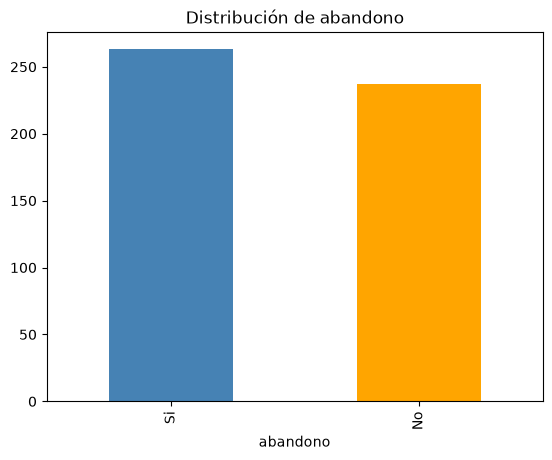

In [7]:
df["abandono"].value_counts().plot(kind="bar", color=["steelblue","orange"])
plt.title("Distribución de abandono")
plt.show()


### 3.3 Visualizaciones

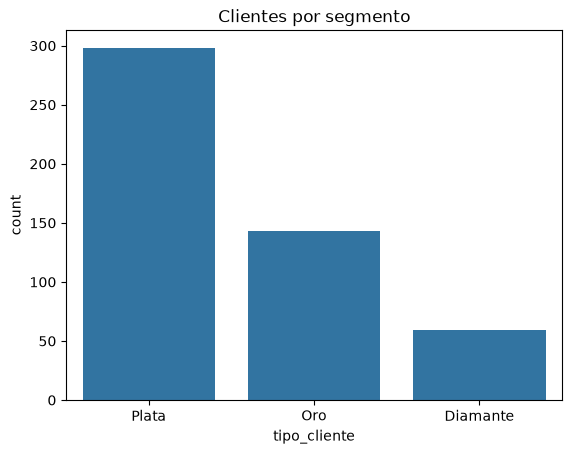

In [8]:
sns.countplot(data=df,x="tipo_cliente")
plt.title("Clientes por segmento")
plt.show()


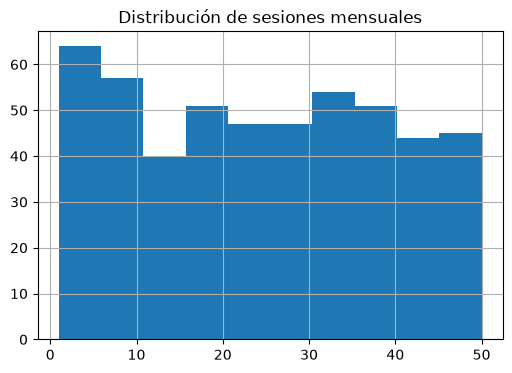

In [9]:
plt.figure(figsize=(6,4))
df["sesiones_mes"].hist()
plt.title("Distribución de sesiones mensuales")
plt.show()


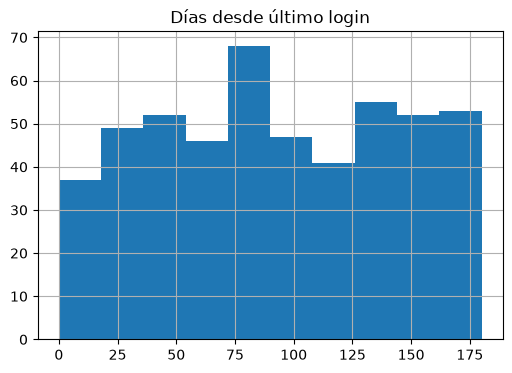

In [10]:
plt.figure(figsize=(6,4))
df["dias_desde_ultimo_login"].hist()
plt.title("Días desde último login")
plt.show()


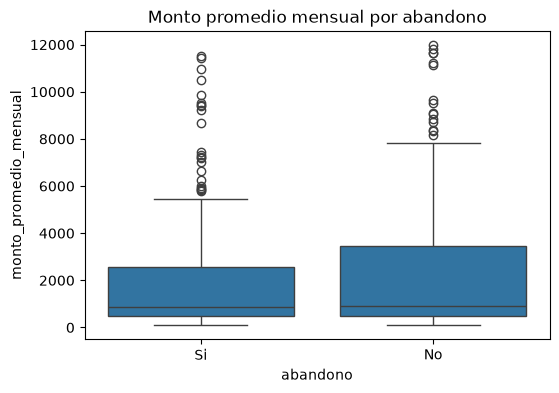

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="abandono",y="monto_promedio_mensual")
plt.title("Monto promedio mensual por abandono")
plt.show()


### 3.4 Correlaciones

In [12]:
num=df[["monto_promedio_mensual","cantidad_transacciones_mes","frecuencia_uso_app","sesiones_mes","dias_desde_ultimo_login","promociones_abiertas","cantidad_quejas","productos_activos"]]
cor=num.corr()
cor


,monto_promedio_mensual,cantidad_transacciones_mes,frecuencia_uso_app,sesiones_mes,dias_desde_ultimo_login,promociones_abiertas,cantidad_quejas,productos_activos
monto_promedio_mensual,1.000000,0.014680,0.009897,-0.012725,-0.015589,-0.031832,-0.051285,-0.075196
cantidad_transacciones_mes,0.014680,1.000000,-0.021770,0.022380,-0.088273,0.025892,0.045128,0.039724
frecuencia_uso_app,0.009897,-0.021770,1.000000,0.016327,0.028411,0.061150,-0.015682,-0.037067
sesiones_mes,-0.012725,0.022380,0.016327,1.000000,-0.007111,-0.016365,-0.004935,0.029179
dias_desde_ultimo_login,-0.015589,-0.088273,0.028411,-0.007111,1.000000,-0.022114,-0.032138,0.042706
promociones_abiertas,-0.031832,0.025892,0.061150,-0.016365,-0.022114,1.000000,0.000329,-0.080841
cantidad_quejas,-0.051285,0.045128,-0.015682,-0.004935,-0.032138,0.000329,1.000000,0.089450
productos_activos,-0.075196,0.039724,-0.037067,0.029179,0.042706,-0.080841,0.089450,1.000000


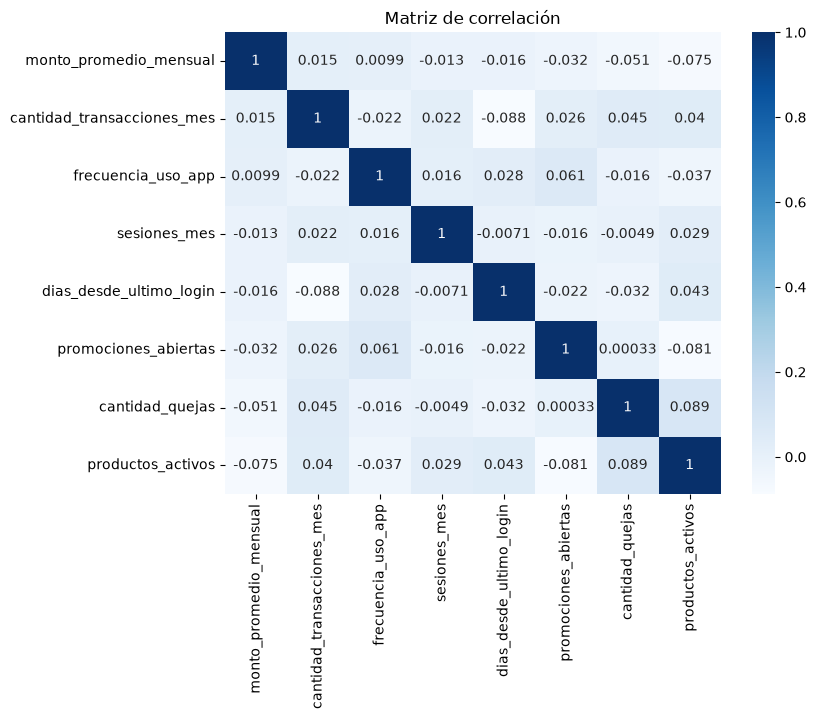

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(cor,annot=True,cmap="Blues")
plt.title("Matriz de correlación")
plt.show()


### 3.5 Verificación de supuesto del algoritmo

Para Regresión Logística se revisará el balance de clases y posibles correlaciones elevadas entre variables.

In [14]:
df["abandono"].value_counts(normalize=True)


abandono
Si    0.526
No    0.474
Name: proportion, dtype: float64

In [15]:
cor.abs().max().sort_values(ascending=False)


monto_promedio_mensual        1.0
cantidad_transacciones_mes    1.0
frecuencia_uso_app            1.0
sesiones_mes                  1.0
dias_desde_ultimo_login       1.0
promociones_abiertas          1.0
cantidad_quejas               1.0
productos_activos             1.0
dtype: float64

### Conclusiones
- Se revisó la estructura del dataset.
- Se analizaron distribuciones y correlaciones.
- Se verificó el balance de clases.
- No se observan problemas evidentes para iniciar el modelado.